# ⚽ Player Detection and Tracking (YOLOv8 + BYTETrack + ReID)


In [5]:
import cv2
from ultralytics import YOLO

video_path = r"C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/15sec_input_720p.mp4"
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)  # skip to frame 100
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("❌ Couldn't read frame from video")

model = YOLO("C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/best.pt")
results = model.predict(source=frame, conf=0.25, imgsz=640)[0]

print("Classes Detected:", results.boxes.cls.cpu().numpy())
print("Box Coordinates:", results.boxes.xyxy.cpu().numpy())



0: 384x640 1 ball, 17 players, 2 referees, 28.9ms
Speed: 1.2ms preprocess, 28.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Classes Detected: [          2           2           2           2           2           2           2           2           2           2           2           2           2           3           3           2           2           0           2           2]
Box Coordinates: [[     804.03       359.5      856.08      448.81]
 [     917.53      346.75      967.97      443.32]
 [     15.298      382.36      75.845      484.35]
 [     965.08      168.66      1000.3      230.63]
 [     122.15      461.46      174.94      578.72]
 [      349.3      127.52      383.91      184.91]
 [     1227.8      210.58      1269.8      272.86]
 [     1006.1      320.82      1042.7      390.32]
 [     572.17      128.31      602.62       183.9]
 [     641.98      242.74      681.71      313.56]
 [     549.17      373.29      594.51      468.28]
 [     329.57 

## 🎯 Tracking Pipeline Overview

- **Detector**: YOLOv8 (custom-trained)
- **Tracker**: BYTETrack
- **ReID**: TorchReID (osnet_x0_25)
- **Enhancements**:
  - Appearance-based ID assignment
  - ID recycling
  - Position-aware similarity


In [14]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
from yolox.tracker.byte_tracker import BYTETracker
from loguru import logger
from types import SimpleNamespace
from collections import defaultdict, deque
import time
import torch
import torchreid

# Configuration
VIDEO_PATH = r"C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/15sec_input_720p.mp4"
OUTPUT_DIR = r"C:/Users/LIGHTRQX/Desktop/my_babies/output/bytetrack"
MODEL_PATH = r"C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/best.pt"
REID_MODEL_PATH = r"osnet_x0_25_msmt17.pt"  # Pre-trained ReID model

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# FINE-TUNED TRACKING PARAMETERS FOR LAST 5 SECONDS
DETECTION_CONF = 0.45         # Slightly lower confidence for more detections
TRACK_CONF = 0.6              # Higher tracking confidence threshold
MATCH_THRESH = 0.85           # Stricter matching threshold
TRACK_BUFFER = 120            # 4-second buffer at 30fps (120 frames)
MIN_HEIGHT = 20               # Minimum height for players
FRAME_RATE = 30               # Assuming 30fps video
MIN_TRACK_FRAMES = 8          # Require more frames for stable track
REID_THRESHOLD = 0.75         # Higher similarity threshold for re-identification
MAX_AGE = 45                  # Longer time to keep inactive tracks
MAX_PLAYERS = 25              # Increased max players

# Initialize ReID model
reid_model = torchreid.models.build_model(
    'osnet_x0_25',
    num_classes=1000,
    pretrained=True
)
reid_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
reid_model = reid_model.to(device)

# Color palette for players (extended)
COLORS = [(0, 255, 0), (0, 0, 255), (255, 0, 0), (255, 255, 0),
          (0, 255, 255), (255, 0, 255), (255, 128, 0), (128, 0, 128),
          (0, 128, 128), (128, 128, 0), (128, 0, 0), (0, 128, 0),
          (0, 0, 128), (128, 128, 128), (192, 192, 192), (255, 165, 0),
          (75, 0, 130), (139, 69, 19), (255, 192, 203), (0, 255, 127),
          (30, 144, 255), (255, 20, 147), (60, 179, 113), (210, 105, 30),
          (0, 191, 255)]

# Initialize detection model
model = YOLO(MODEL_PATH).to(device)

# FINE-TUNED TRACKER CONFIGURATION
tracker_args = SimpleNamespace(
    track_thresh=TRACK_CONF,
    match_thresh=MATCH_THRESH,
    track_buffer=TRACK_BUFFER,
    aspect_ratio_thresh=3.5,  # Better for player aspect ratios
    min_box_area=MIN_HEIGHT*MIN_HEIGHT,
    mot20=True                # Enable MOT20 compatibility
)
tracker = BYTETracker(tracker_args, frame_rate=FRAME_RATE)

# Video processing setup
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise IOError(f"Cannot open video {VIDEO_PATH}")

w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_video_path = os.path.join(OUTPUT_DIR, "tracked_output.mp4")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

# Persistent identity management
class PlayerIdentity:
    def __init__(self, persistent_id, frame_idx):
        self.persistent_id = persistent_id
        self.track_history = deque(maxlen=50)  # Longer history
        self.appearance_features = None
        self.first_seen = frame_idx  # Track when ID was first assigned
        self.last_seen = frame_idx
        self.active = False
        self.color = COLORS[persistent_id % len(COLORS)]  # Safe color selection
        self.occurrence_count = 0
        self.last_position = None  # Store last known position

    def update(self, position, appearance_feature, frame_idx):
        self.track_history.append(position)
        self.last_position = position
        # Update appearance feature with moving average
        if self.appearance_features is None:
            self.appearance_features = appearance_feature
        else:
            self.appearance_features = 0.8 * self.appearance_features + 0.2 * appearance_feature
        self.last_seen = frame_idx
        self.active = True
        self.occurrence_count += 1

    def similarity(self, other_feature):
        if self.appearance_features is None or other_feature is None:
            return 0
        return np.dot(self.appearance_features, other_feature) / (
            np.linalg.norm(self.appearance_features) * np.linalg.norm(other_feature)
        )

# Identity manager with ID recycling
class IdentityManager:
    def __init__(self, max_players=MAX_PLAYERS):
        self.max_players = max_players
        self.identities = {}  # persistent_id -> PlayerIdentity
        self.active_identities = set()
        self.available_ids = deque(range(max_players))  # Start with all IDs available
        self.id_last_used = {}  # Track when each ID was last used
    
    def create_new_identity(self, position, appearance_feature, frame_idx):
        if not self.available_ids:
            # Recycle the least recently used inactive ID
            inactive_ids = [pid for pid in self.identities.keys() if not self.identities[pid].active]
            if not inactive_ids:
                logger.warning("All IDs active! Cannot create new identity")
                return None
                
            # Find least recently used inactive ID
            oldest_id = min(inactive_ids, key=lambda pid: self.id_last_used[pid])
            pid = oldest_id
            logger.debug(f"Recycling ID {pid}")
            # Reset the identity
            self.identities[pid] = PlayerIdentity(pid, frame_idx)
        else:
            # Take next available ID
            pid = self.available_ids.popleft()
            # Create new identity
            self.identities[pid] = PlayerIdentity(pid, frame_idx)
        
        # Update the identity
        self.identities[pid].update(position, appearance_feature, frame_idx)
        self.active_identities.add(pid)
        self.id_last_used[pid] = frame_idx
        return pid
    
    def update_identity(self, pid, position, appearance_feature, frame_idx):
        if pid in self.identities:
            self.identities[pid].update(position, appearance_feature, frame_idx)
            self.active_identities.add(pid)
            self.id_last_used[pid] = frame_idx
    
    def get_similar_identity(self, appearance_feature, position, frame_idx):
        best_match = None
        best_score = REID_THRESHOLD
        
        for pid, identity in self.identities.items():
            # Skip active identities
            if identity.active:
                continue
                
            # Check if identity is too old
            if frame_idx - identity.last_seen > MAX_AGE:
                continue
                
            # Calculate appearance similarity
            similarity = identity.similarity(appearance_feature)
            
            # Position consistency check (if available)
            if identity.last_position:
                last_pos = identity.last_position
                distance = np.sqrt((position[0]-last_pos[0])**2 + (position[1]-last_pos[1])**2)
                # Penalize large movements with exponential decay
                position_weight = np.exp(-distance/100)
                similarity *= position_weight
            
            if similarity > best_score:
                best_score = similarity
                best_match = pid
        
        return best_match, best_score
    
    def end_frame(self, frame_idx):
        # Deactivate identities not updated this frame
        inactive = []
        for pid in self.active_identities:
            if not self.identities[pid].active:
                inactive.append(pid)
            else:
                self.identities[pid].active = False  # Reset for next frame
                
        # Remove inactive from active set
        for pid in inactive:
            self.active_identities.remove(pid)
            
        # Return IDs to available pool if expired
        expired_ids = []
        for pid, identity in self.identities.items():
            if not identity.active and (frame_idx - identity.last_seen > MAX_AGE):
                expired_ids.append(pid)
                
        for pid in expired_ids:
            if pid not in self.available_ids:
                self.available_ids.append(pid)
                logger.debug(f"Returned ID {pid} to available pool")

# Initialize identity manager with max players
identity_manager = IdentityManager(max_players=MAX_PLAYERS)

# Feature extraction function
def extract_appearance_feature(frame, bbox):
    x1, y1, x2, y2 = map(int, bbox)
    # Ensure valid crop coordinates
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(frame.shape[1], x2)
    y2 = min(frame.shape[0], y2)
    
    # Check for valid crop size
    if x2 <= x1 or y2 <= y1 or (x2 - x1) < 10 or (y2 - y1) < 10:
        return None
        
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
        
    # Preprocess for ReID model
    crop = cv2.resize(crop, (128, 256))
    crop = crop[:, :, ::-1].transpose(2, 0, 1)  # BGR to RGB, HWC to CHW
    crop = np.ascontiguousarray(crop, dtype=np.float32)
    crop /= 255.0  # Normalize
    
    # Extract feature
    with torch.no_grad():
        tensor = torch.from_numpy(crop).unsqueeze(0).to(device).float()  # Ensure float32
        feature = reid_model(tensor).cpu().numpy().flatten()
    
    return feature / (np.linalg.norm(feature) + 1e-12)  # Normalize with epsilon

logger.info(f"Starting tracking - Video: {w}x{h} | FPS: {fps} | Frames: {total_frames}")
logger.info(f"Using fixed ID pool of {MAX_PLAYERS} identities")

for frame_idx in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break

    # Run detection
    results = model.predict(
        source=frame,
        conf=DETECTION_CONF,
        imgsz=640,
        verbose=False
    )
    
    # Process detections - only players (class 2)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy()
    clss = results[0].boxes.cls.cpu().numpy().astype(int)
    
    detections = []
    for box, score, cls in zip(boxes, scores, clss):
        if cls == 2:  # Player class
            x1, y1, x2, y2 = box
            height = y2 - y1
            if height >= MIN_HEIGHT:
                detections.append([x1, y1, x2, y2, score])
    
    # Format detections for tracker
    det_np = np.array(detections, dtype=np.float32) if detections else np.zeros((0, 5), dtype=np.float32)
    
    # Update tracker
    online_targets = tracker.update(det_np, (h, w), (h, w))
    
    # Visualization
    vis_frame = frame.copy()
    stable_player_count = 0
    
    # Process tracked objects
    for t in online_targets:
        # Get bounding box coordinates
        x1, y1 = int(t.tlwh[0]), int(t.tlwh[1])
        w_box, h_box = int(t.tlwh[2]), int(t.tlwh[3])
        x2, y2 = x1 + w_box, y1 + h_box
        center = ((x1 + x2) // 2, (y1 + y2) // 2)
        bbox = (x1, y1, x2, y2)
        
        # Extract appearance feature
        appearance_feature = extract_appearance_feature(frame, bbox)
        
        # Find or create identity
        persistent_id = None
        
        # Try to match with existing identities
        if appearance_feature is not None:
            match_id, match_score = identity_manager.get_similar_identity(
                appearance_feature, center, frame_idx
            )
            if match_id is not None:
                persistent_id = match_id
                identity_manager.update_identity(
                    persistent_id, center, appearance_feature, frame_idx
                )
                logger.debug(f"Re-identified player {persistent_id} with score {match_score:.2f}")
        
        # Create new identity if no match found
        if persistent_id is None:
            persistent_id = identity_manager.create_new_identity(
                center, appearance_feature, frame_idx
            )
            if persistent_id is not None:
                logger.debug(f"Created new identity {persistent_id}")
        
        # Skip if we couldn't assign an ID
        if persistent_id is None:
            continue
        
        # Get identity object
        identity = identity_manager.identities[persistent_id]
        
        # Only display tracks that have been stable
        if identity.occurrence_count < MIN_TRACK_FRAMES:
            continue
            
        stable_player_count += 1
        
        # Draw bounding box with persistent ID
        cv2.rectangle(vis_frame, (x1, y1), (x2, y2), identity.color, 2)
        label = f"ID:{persistent_id}"
        cv2.putText(vis_frame, label, (x1, y1-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, identity.color, 2)
        
        # Draw tracking path
        if len(identity.track_history) > 1:
            pts = np.array(identity.track_history, np.int32)
            cv2.polylines(vis_frame, [pts], False, identity.color, 2)
    
    # End of frame processing
    identity_manager.end_frame(frame_idx)
    
    # Display frame info
    cv2.putText(vis_frame, f"Frame: {frame_idx}/{total_frames-1}", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(vis_frame, f"Players: {stable_player_count}", (10, 60),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(vis_frame, f"Detections: {len(detections)}", (10, 90),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(vis_frame, f"Available IDs: {len(identity_manager.available_ids)}", (10, 120),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    out.write(vis_frame)
    
    # Progress logging
    if frame_idx % 10 == 0 or frame_idx == total_frames - 1:
        active_count = len(identity_manager.active_identities)
        logger.info(f"Frame {frame_idx:03d} | Players: {stable_player_count} | Active IDs: {active_count} | Detections: {len(detections)}")

# Cleanup
cap.release()
out.release()

logger.success("Tracking completed successfully!")
logger.info(f"Output video saved to: {output_video_path}")

# Save ID mapping information
id_mapping_path = os.path.join(OUTPUT_DIR, "id_mapping.txt")
with open(id_mapping_path, 'w') as f:
    f.write("Player ID Mapping Information:\n")
    f.write(f"Total IDs used: {len(identity_manager.identities)}\n")
    f.write("ID,First Seen,Last Seen,Occurrences\n")
    for pid, identity in identity_manager.identities.items():
        f.write(f"{pid},{identity.first_seen},{identity.last_seen},{identity.occurrence_count}\n")

logger.info(f"ID mapping information saved to: {id_mapping_path}")

Successfully loaded imagenet pretrained weights from "C:\Users\LIGHTRQX/.cache\torch\checkpoints\osnet_x0_25_imagenet.pth"


2025-06-30 16:33:31.222 | INFO     | __main__:<module>:239 - Starting tracking - Video: 1280x720 | FPS: 25.0 | Frames: 375
2025-06-30 16:33:31.224 | INFO     | __main__:<module>:240 - Using fixed ID pool of 25 identities
2025-06-30 16:33:31.761 | DEBUG    | __main__:<module>:311 - Created new identity 0
2025-06-30 16:33:31.776 | DEBUG    | __main__:<module>:311 - Created new identity 1
2025-06-30 16:33:31.790 | DEBUG    | __main__:<module>:311 - Created new identity 2
2025-06-30 16:33:31.805 | DEBUG    | __main__:<module>:311 - Created new identity 3
2025-06-30 16:33:31.821 | DEBUG    | __main__:<module>:311 - Created new identity 4
2025-06-30 16:33:31.836 | DEBUG    | __main__:<module>:311 - Created new identity 5
2025-06-30 16:33:31.850 | DEBUG    | __main__:<module>:311 - Created new identity 6
2025-06-30 16:33:31.864 | DEBUG    | __main__:<module>:311 - Created new identity 7
2025-06-30 16:33:31.878 | DEBUG    | __main__:<module>:311 - Created new identity 8
2025-06-30 16:33:31.890

## 📌 Step 3: Analyzing Player Tracking Consistency


C:\Users\LIGHTRQX\AppData\Local\Temp\ipykernel_39084\2873047978.py:29: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LIGHTRQX\AppData\Local\Temp\ipykernel_39084\2873047978.py:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LIGHTRQX\AppData\Local\Temp\ipykernel_39084\2873047978.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LIGHTRQX\yolovenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\LIGHTRQX\yolovenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\LIGHTRQX\yolovenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT

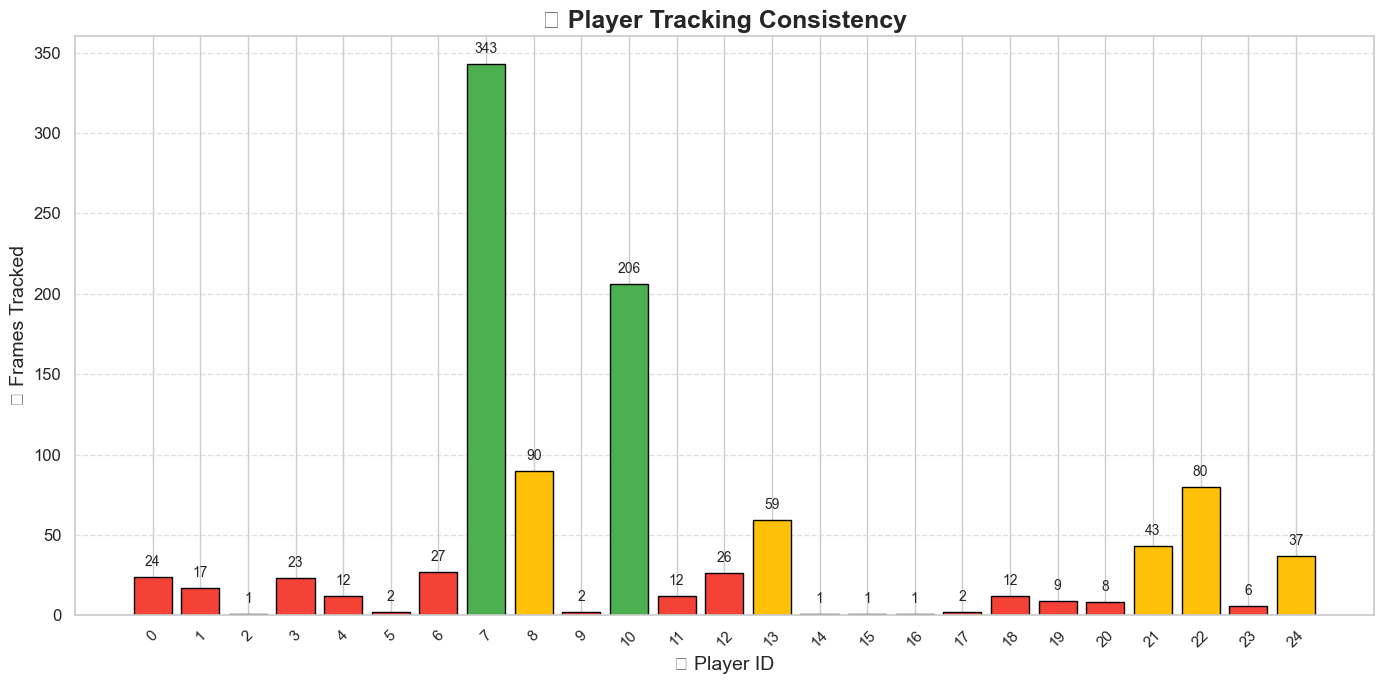

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# === Nice Style Setup ===
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))

# === Bar Colors Based on Frames Tracked ===
colors = ["#4CAF50" if f > 100 else "#FFC107" if f > 30 else "#F44336" for f in frame_counts]

# === Bar Plot ===
bars = plt.bar(sorted_ids, frame_counts, color=colors, edgecolor='black')

# === Labels and Title ===
plt.xlabel("👤 Player ID", fontsize=14)
plt.ylabel("📊 Frames Tracked", fontsize=14)
plt.title("🎯 Player Tracking Consistency", fontsize=18, fontweight='bold')
plt.xticks(sorted_ids, rotation=45)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# === Highlight Bars with Annotations ===
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f'{yval}', ha='center', va='bottom', fontsize=10)

# === Layout and Show ===
plt.tight_layout()
plt.show()
